<br>

<div align="center">
<span style="font-size: 2.5em;">Monte Carlo Recoil Spectra Visualization</span>
<br>
<span style="font-size: 1.2em; color: gray;">Exploring binning strategies for different DM masses and couplings</span>
</div>

## Overview

This notebook visualizes WIMP recoil energy spectra for different parameter combinations, comparing linear and logarithmic binning strategies.

### Key Considerations

**Binning Strategy**: 
- Recoil spectra are exponentially distributed
- Logarithmic bins provide better resolution in high-event regions
- Linear bins useful for visualization but may miss structure at low energies

**Physical Constraints**:
- MC threshold: 1.0 keV (realistic threshold would be slightly higher)
- Event rate scales as $\propto c_p^2$
- Target regime: ~100 events → requires moderate coupling values

In [ ]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os
desired_root_name = "xenon-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    
import numpy as np
import matplotlib.pyplot as plt
from data.mc_generator import mc_generator
from configs.config import MCConfig

In [3]:
# =============================
# PARAMETER GRID
# =============================

masses = [5, 50, 500]  # GeV (low, medium, high)
couplings = [1e-8, 1e-9, 1e-10]  # Isoscalar coupling parameter

## 0. Differential Recoil Rates vs. Dark Matter Mass

How does the recoil rate spectrum change with WIMP mass? This section compares differential recoil rates $\frac{dR}{dE}$ across different mass regimes for a fixed coupling strength.

**Key Physics**:
- Light WIMPs: Produce abundant but soft recoils (low energies)
- Heavy WIMPs: Produce fewer but harder recoils (high energies)
- Rate scales as $\propto c_p^2$ independently of mass
- Different kinematics lead to very different energy distributions

Figure saved to figures/chap3/recoil_rate_xenon.pdf


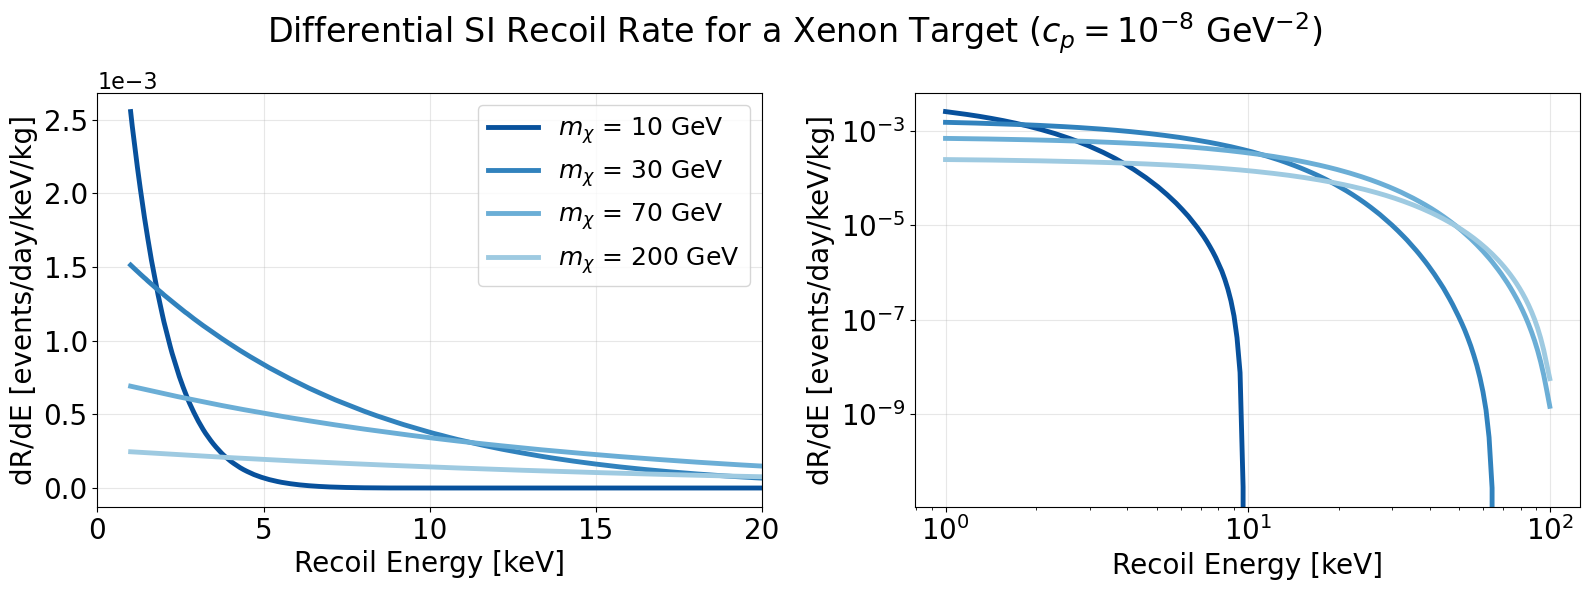

In [9]:
# =============================
# DIFFERENTIAL RATES FOR VARYING MASS
# =============================

from data.mc_generator import calculate_diff_rate

# Energy range for evaluation
er_min, er_max = 1.0, 100.0
n_points = 200
er_vec = np.logspace(np.log10(er_min), np.log10(er_max), n_points)

# Fixed coupling and varying masses
fixed_coupling = 1e-8
masses_to_compare = [10, 30, 70, 200]

# Compute rates for each mass
rates_by_mass = {}
for mass in masses_to_compare:
    diff_rate = calculate_diff_rate(mchi=mass, c_p=fixed_coupling, er_vec=er_vec)
    rates_by_mass[mass] = diff_rate

# Blue color palette (from light to dark blue)
blues = ['#08519c', '#3182bd', '#6baed6', '#9ecae1']

# Plot differential rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale on both axes
for idx, mass in enumerate(masses_to_compare):
    ax1.plot(er_vec, rates_by_mass[mass], label=f"$m_\chi$ = {mass} GeV", 
             linewidth=3.5, color=blues[idx])

ax1.set_xlabel("Recoil Energy [keV]", fontsize=20)
ax1.set_ylabel("dR/dE [events/day/keV/kg]", fontsize=20)
ax1.legend(fontsize=18, ncol=1, loc='upper right')
ax1.grid(alpha=0.3, linewidth=0.8)
ax1.tick_params(labelsize=20)
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax1.set_xlim(0, 20)
ax1.yaxis.get_offset_text().set_fontsize(16)

# Log scale on both axes
for idx, mass in enumerate(masses_to_compare):
    ax2.loglog(er_vec, rates_by_mass[mass], label=f"$m_\chi$ = {mass} GeV", 
               linewidth=3.5, color=blues[idx])

ax2.set_xlabel("Recoil Energy [keV]", fontsize=20)
ax2.set_ylabel("dR/dE [events/day/keV/kg]", fontsize=20)
#ax2.legend(fontsize=18, ncol=1, loc='lower left')
ax2.tick_params(labelsize=20)
ax2.grid(alpha=0.3, linewidth=0.8, which='major')

# Single figure title
exp = int(f"{fixed_coupling:.0e}".split("e")[1])
fig.suptitle(rf"Differential SI Recoil Rate for a Xenon Target ($c_p = 10^{{{exp}}}~\mathrm{{GeV}}^{{-2}}$)", 
             fontsize=24, y=0.975)
plt.tight_layout()

# Save figure to PDF
pdf_path = "figures/chap3/recoil_rate_xenon.pdf"
fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved to {pdf_path}")

plt.show()

## 1. Linear Binning

Standard histogram with linearly spaced energy bins.

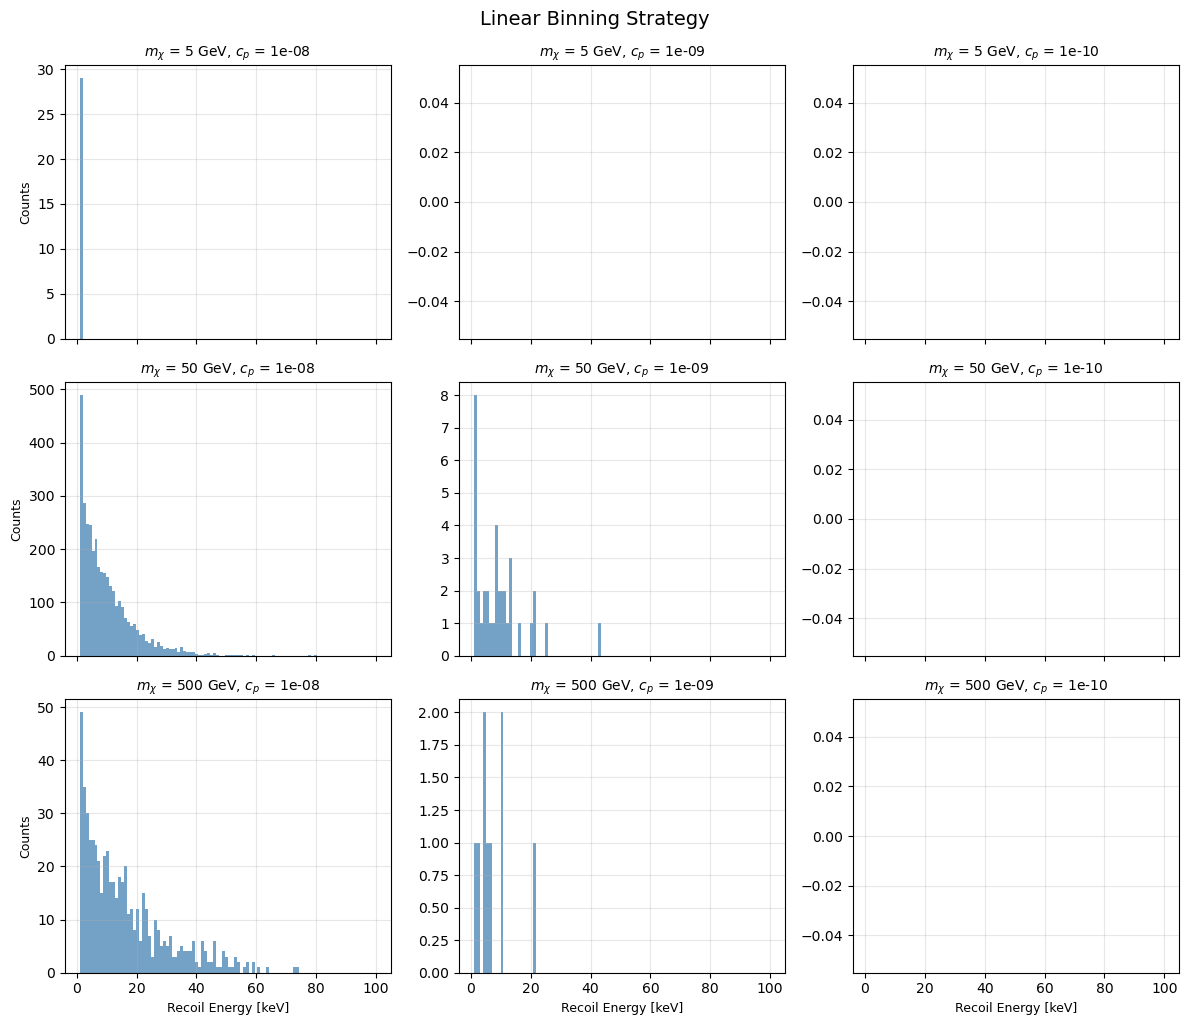

In [3]:
# =============================
# PLOT: LINEAR BINS, LINEAR COUNTS
# =============================

mc_cfg = MCConfig(log_bins=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=False)

for i, mchi in enumerate(masses):
    for j, cp in enumerate(couplings):
        ax = axes[i, j]
        
        # Generate spectrum
        events, counts, bin_edges, nevents = mc_generator(mchi=mchi, cp=cp, **mc_cfg.__dict__)
        
        # Plot histogram
        ax.hist(events, bins=bin_edges, color='steelblue', alpha=0.75, linewidth=0.5)
        ax.set_title(f"$m_\chi$ = {mchi} GeV, $c_p$ = {cp:.0e}", fontsize=10)
        
        # Labels
        if i == 2:
            ax.set_xlabel("Recoil Energy [keV]", fontsize=9)
        if j == 0:
            ax.set_ylabel("Counts", fontsize=9)
        
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Linear Binning Strategy", fontsize=14, y=1.02)
plt.show()

In [4]:
# Example: inspect bin contents
events, counts, bin_edges, nevents = mc_generator(mchi=50, cp=1e-8, **mc_cfg.__dict__)

print(f"Total events: {nevents}")
print(f"Bin counts: {counts[:10]}...")  # Show first 10 bins

Total events: 3434
Bin counts: [457 287 259 217 223 192 172 145 148 135]...


## 2. Logarithmic Binning (Linear Counts)

Logarithmically spaced energy bins to better capture the exponential spectrum shape.

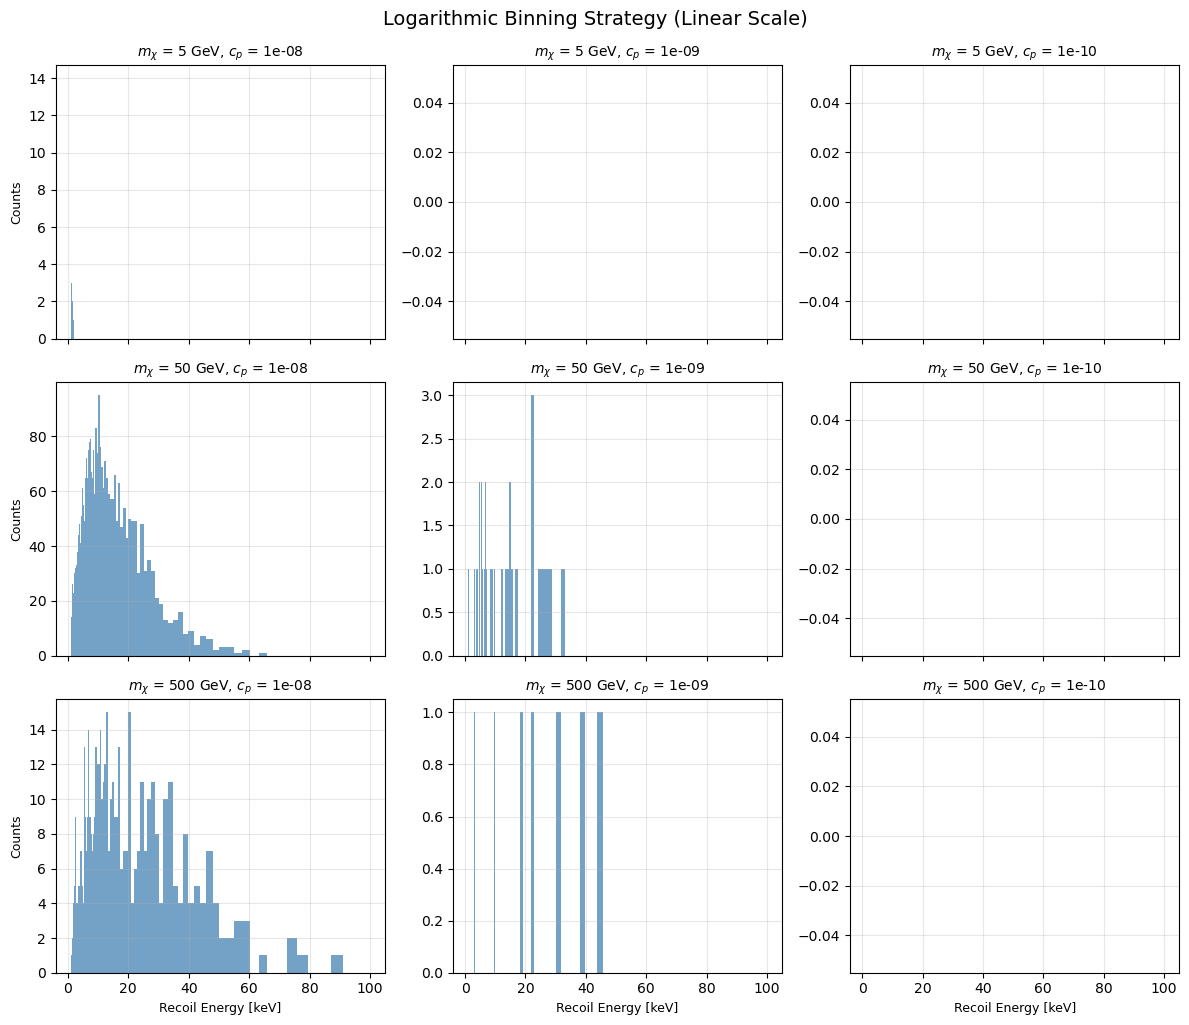

In [5]:
# =============================
# PLOT: LOG BINS, LINEAR COUNTS
# =============================

mc_cfg = MCConfig(log_bins=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=False)

for i, mchi in enumerate(masses):
    for j, cp in enumerate(couplings):
        ax = axes[i, j]
        
        # Generate spectrum
        events, counts, bin_edges, nevents = mc_generator(mchi=mchi, cp=cp, **mc_cfg.__dict__)
        
        # Plot histogram
        ax.hist(events, bins=bin_edges, color='steelblue', alpha=0.75, linewidth=0.5)
        ax.set_title(f"$m_\chi$ = {mchi} GeV, $c_p$ = {cp:.0e}", fontsize=10)
        
        # Labels
        if i == 2:
            ax.set_xlabel("Recoil Energy [keV]", fontsize=9)
        if j == 0:
            ax.set_ylabel("Counts", fontsize=9)
        
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("Logarithmic Binning Strategy (Linear Scale)", fontsize=14, y=1.02)
plt.show()

In [6]:
# Example: inspect bin contents with log bins
events, counts, bin_edges, nevents = mc_generator(mchi=50, cp=1e-8, **mc_cfg.__dict__)

print(f"Total events: {nevents}")
print(f"Bin counts: {counts[:10]}...")  # Show first 10 bins
print(f"Bin edges (first 5): {bin_edges[:5]}")

Total events: 3497
Bin counts: [17 28 21 24 18 23 26 26 21 24]...
Bin edges (first 5): [1.         1.04712855 1.0964782  1.14815362 1.20226443]


## 3. Logarithmic Binning (Log Counts)

Logarithmically spaced bins with log-scale counts for better visualization across different event rate scales.

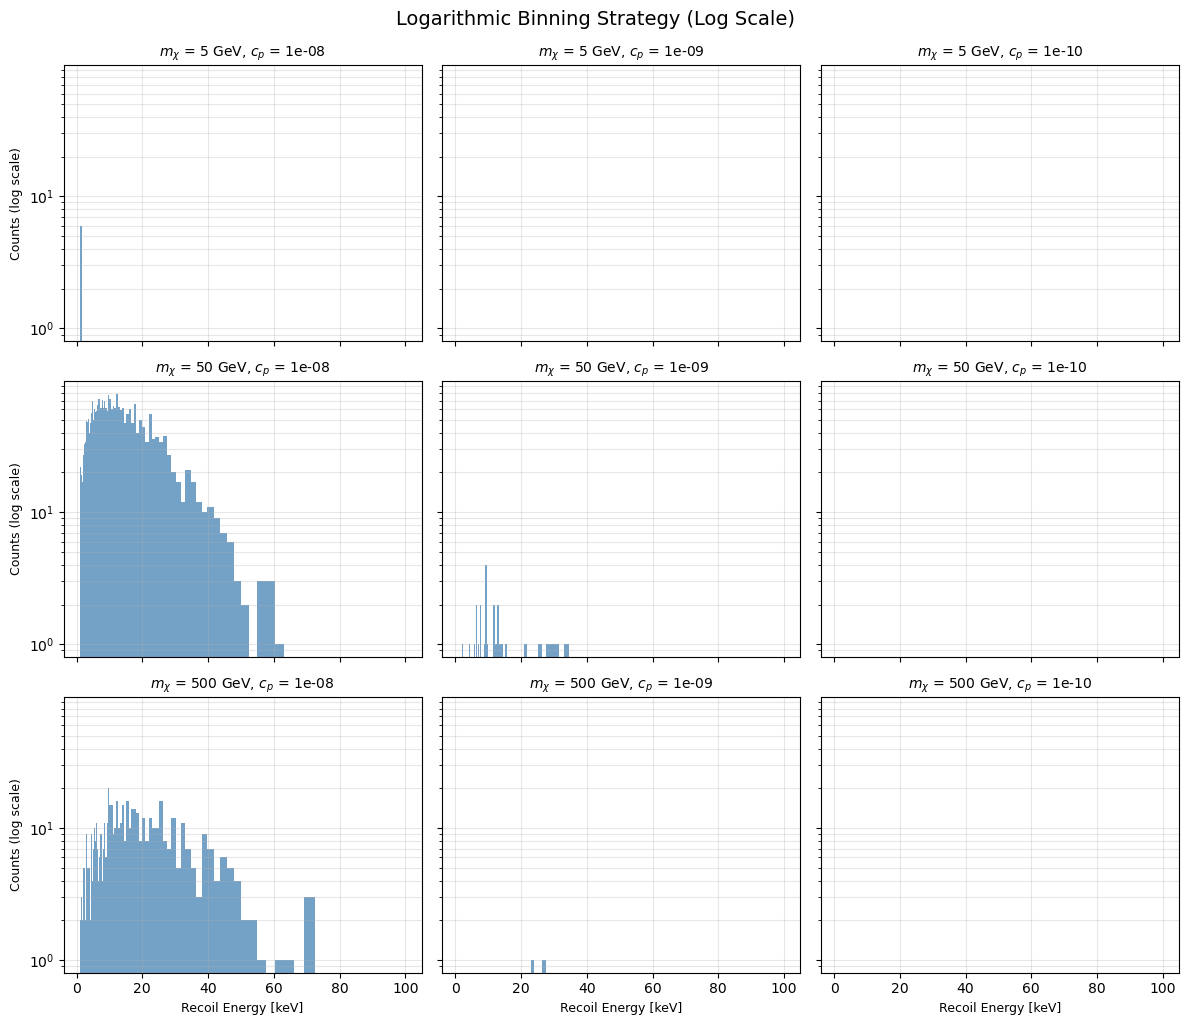

In [7]:
# =============================
# PLOT: LOG BINS, LOG COUNTS
# =============================

fig, axes = plt.subplots(3, 3, figsize=(12, 10), sharex=True, sharey=True)

for i, mchi in enumerate(masses):
    for j, cp in enumerate(couplings):
        ax = axes[i, j]
        
        # Generate spectrum
        events, counts, bin_edges, nevents = mc_generator(mchi=mchi, cp=cp, **mc_cfg.__dict__)
        
        # Plot histogram with log scale
        ax.hist(events, bins=bin_edges, color='steelblue', alpha=0.75, 
                linewidth=0.5, log=True)
        ax.set_title(f"$m_\chi$ = {mchi} GeV, $c_p$ = {cp:.0e}", fontsize=10)
        
        # Labels
        if i == 2:
            ax.set_xlabel("Recoil Energy [keV]", fontsize=9)
        if j == 0:
            ax.set_ylabel("Counts (log scale)", fontsize=9)
        
        ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.suptitle("Logarithmic Binning Strategy (Log Scale)", fontsize=14, y=1.02)
plt.show()

In [8]:
# Example: inspect log-transformed bin contents
events, counts, bin_edges, nevents = mc_generator(mchi=50, cp=1e-8, **mc_cfg.__dict__)

print(f"Total events: {nevents}")
print(f"Log(counts + 1) for first 10 bins: {np.log10(counts[:10] + 1)}")
print(f"Log(total events + 1): {np.log10(nevents + 1):.2f}")

Total events: 3460
Log(counts + 1) for first 10 bins: [1.49136169 1.20411998 1.2787536  1.34242268 1.32221929 1.32221929
 1.47712125 1.34242268 1.30103    1.2787536 ]
Log(total events + 1): 3.54


<br>

## Summary

**Binning Strategy Recommendations**:

- **Linear bins**: Good for qualitative visualization, but poor resolution at low energies where most events occur
- **Log bins + linear counts**: Better resolution across energy range, suitable for moderate event counts
- **Log bins + log counts**: Best for comparing spectra across different coupling strengths and event rate scales

**Data Representation**:
- Log transformation of bin contents (`log(counts + 1)`) is beneficial when $c_p$ varies widely
- For moderate $c_p$ values targeting ~100 events, linear representation of log-binned data is often sufficient

<br><br><br><br><br>

## Additional Two-Parameter Histogram Comparison

Side-by-side comparison for two selected $(m_\chi, c_p)$ pairs with larger text for presentation readability.

Figure saved to figures/chap3/mc_two_True.pdf


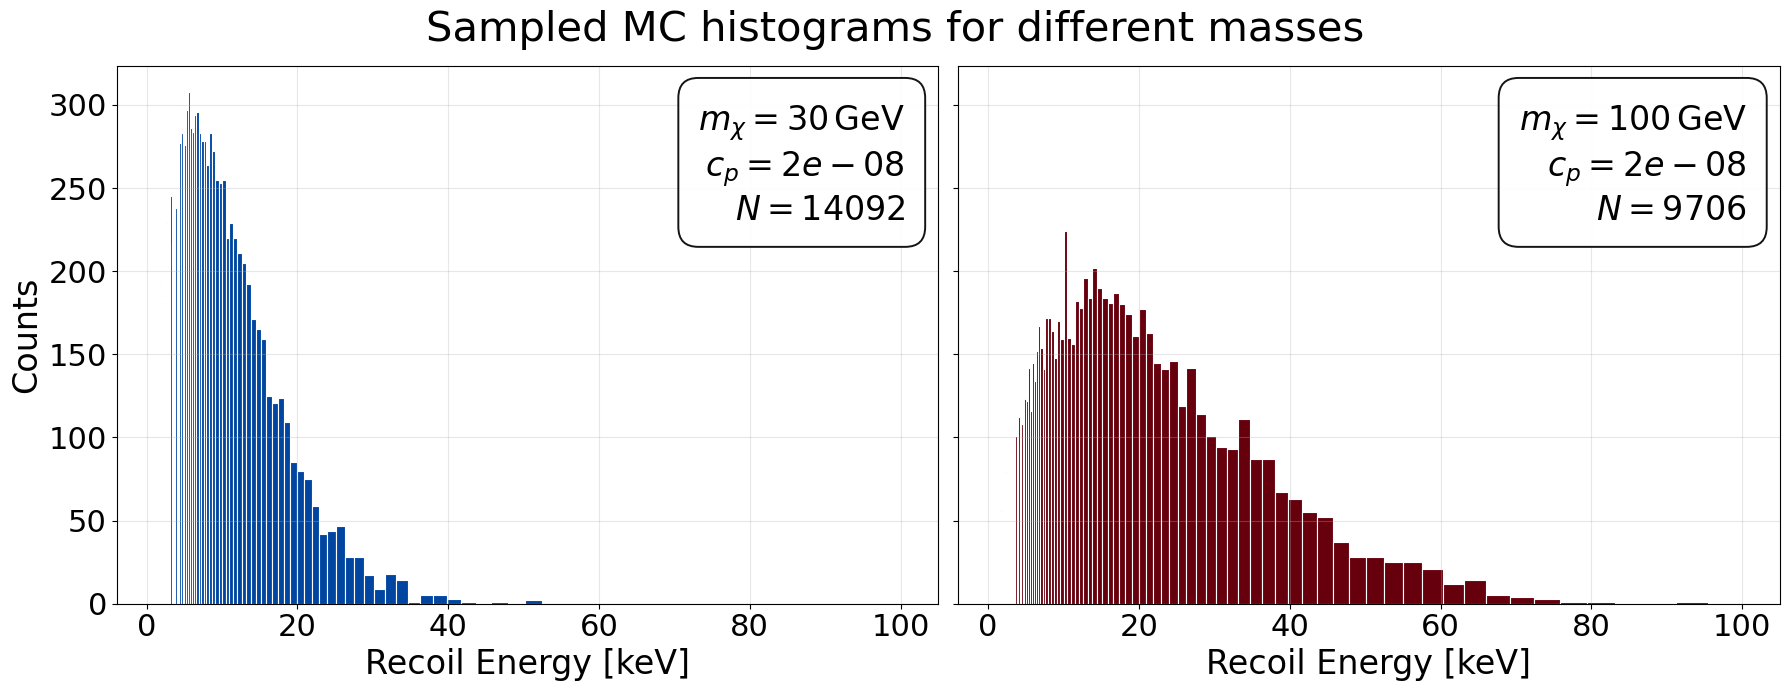

In [10]:
# =============================
# CUSTOM COMPARISON: TWO PARAMETER PAIRS
# =============================

# Two pairs chosen to show a clear difference
pairs = [
    (30, 2e-8),
    (100, 2e-8),
]

blue_rgb = (0/255, 70/255, 160/255)
panel_colors = [blue_rgb, "#67000d"]

# Keep linear bins for direct shape/count comparison
log_bins = True
compare_cfg = MCConfig(log_bins=log_bins)

# Generate events for both parameter pairs
results = []
for mchi, cp in pairs:
    events, counts, bin_edges, nevents = mc_generator(mchi=mchi, cp=cp, **compare_cfg.__dict__)
    results.append((mchi, cp, events, bin_edges, nevents))


# 1x2 comparison figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, (mchi, cp, events, bin_edges, nevents), color in zip(axes, results, panel_colors):
    ax.hist(events, bins=bin_edges, color=color, alpha=1, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("Recoil Energy [keV]", fontsize=24)
    ax.tick_params(axis="both", labelsize=22)
    ax.grid(alpha=0.3)

    # Boxed parameter annotation inside each panel
    info_text = (
        rf"$m_\chi = {mchi}\,\mathrm{{GeV}}$" + "\n" +
        rf"$c_p = {cp}$" + "\n" +
        rf"$N = {nevents}$"
    )
    ax.text(
        0.96, 0.93, info_text,
        transform=ax.transAxes,
        va="top", ha="right",
        fontsize=24,
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="black", linewidth=1.4, alpha=0.92)
    )

axes[0].set_ylabel("Counts", fontsize=24)
fig.suptitle("Sampled MC histograms for different masses", fontsize=30, y=0.98)
plt.tight_layout()
# Save figure to PDF
pdf_path = f"figures/chap3/mc_two_{log_bins}.pdf"
fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved to {pdf_path}")
plt.show()

Figure saved to figures/chap3/mc_grid_True.pdf


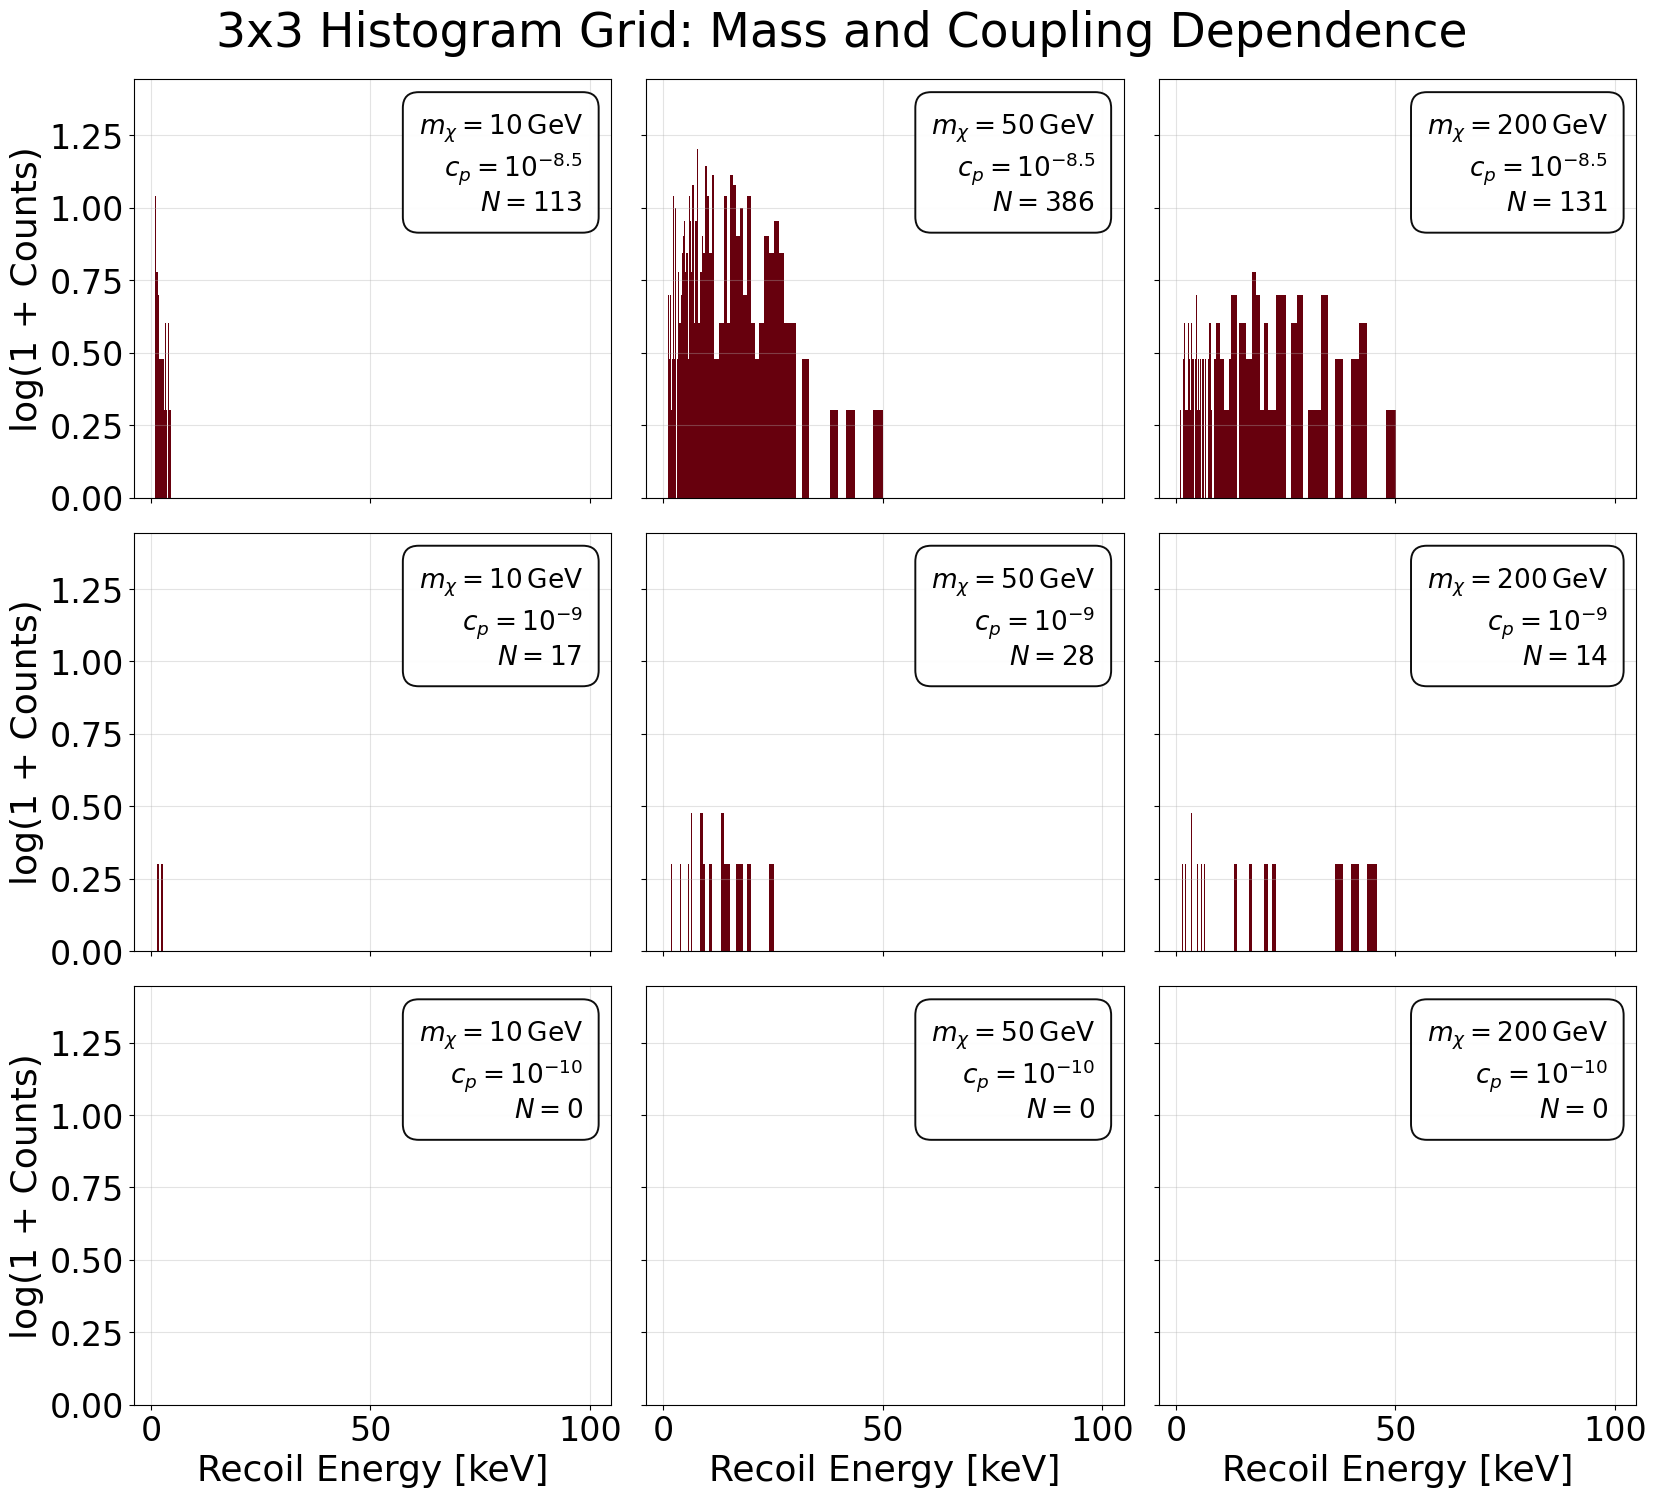

In [29]:
# =============================
# 3x3 GRID COMPARISON WITH BOXED PARAMETERS
# =============================

# Parameter grid setup (same row/column logic as plot_posterior_grid_s1s2)
grid_dim = 3
logms = np.log10(np.array([10, 50, 200], dtype=float))
logcps = np.array([-8.5, -9.0, -10.0], dtype=float)

if len(logms) != grid_dim or len(logcps) != grid_dim:
    raise ValueError("grid_dim must match the number of mass and coupling entries")

masses_grid = np.rint(10**logms).astype(int).tolist()
couplings_grid = (10**logcps).tolist()

# Plot options
use_log_binning = True
use_log1p_transform = True

log_bins = use_log_binning
grid_cfg = MCConfig(log_bins=log_bins)

def cp_power_label(logcp):
    if np.isclose(logcp, round(logcp)):
        exp_str = f"{int(round(logcp))}"
    else:
        exp_str = f"{logcp:.1f}"
    return rf"$c_p = 10^{{{exp_str}}}$"

def format_nevents(nevents):
    if np.isclose(nevents, round(nevents)):
        return str(int(round(nevents)))
    return f"{nevents:.2f}"

# Generate spectra for each row/column combination and compute y-limits
all_spectra = {}
row_max_count = {r: 0.0 for r in range(grid_dim)}
global_max_count = 0.0

for r in range(grid_dim):
    for c in range(grid_dim):
        mchi = float(10**logms[c])
        cp = float(10**logcps[r])
        events, counts, bin_edges, nevents = mc_generator(mchi=mchi, cp=cp, **grid_cfg.__dict__)
        all_spectra[(r, c)] = (events, bin_edges, nevents, counts)
        if counts.size > 0:
            panel_max = np.max(np.log10(counts+1)) if use_log1p_transform else np.max(counts)
            row_max_count[r] = max(row_max_count[r], float(panel_max))
            global_max_count = max(global_max_count, float(panel_max))

# Add headroom and a minimum top so tiny-stat rows still look good
min_top = 1.0 if use_log1p_transform else 5.0
row_ylim = {r: max(min_top, 1.2 * row_max_count[r]) for r in range(grid_dim)}
global_ylim = max(min_top, 1.2 * global_max_count)
blue_rgb = (0/255, 70/255, 160/255)

# {grid_dim}x{grid_dim} figure: rows are fixed-cp, columns are varying mass; y-axis shared only within each row
fig, axes = plt.subplots(
    grid_dim, grid_dim,
    figsize=(5.5 * grid_dim, 5.0 * grid_dim),
    sharex=True, sharey="row"
 )
axes = np.array(axes).reshape(grid_dim, grid_dim)

for r in range(grid_dim):
    for c in range(grid_dim):
        ax = axes[r, c]
        events, bin_edges, nevents, counts = all_spectra[(r, c)]
        mchi = int(round(10**logms[c]))

        color = "#67000d" if use_log1p_transform else blue_rgb
        if use_log1p_transform:
            # Build histogram manually to apply log(1 + count) to bin heights.
            hist_counts, _ = np.histogram(events, bins=bin_edges)
            ax.bar(
                bin_edges[:-1],
                np.log10(hist_counts+1),
                width=np.diff(bin_edges),
                align="edge",
                color=color,
                alpha=1,
                edgecolor="white",
                linewidth=0,
            )
        else:
            ax.hist(events, bins=bin_edges, color=color, alpha=1, linewidth=4)

        # Use one global y-axis for all panels when log(1+x) transform is active.
        if use_log1p_transform:
            ax.set_ylim(0, global_ylim)
        else:
            ax.set_ylim(0, row_ylim[r])

        ax.grid(alpha=0.35, linewidth=0.8)
        ax.tick_params(axis="both", labelsize=24)

        if r == grid_dim - 1:
            ax.set_xlabel("Recoil Energy [keV]", fontsize=26)
        if c == 0:
            ylabel = "log(1 + Counts)" if use_log1p_transform else "Counts"
            ax.set_ylabel(ylabel, fontsize=26)

        # Boxed annotation anchored to the right edge
        n_label = format_nevents(nevents)
        info_text = (
            rf"$m_\chi = {mchi}\,\mathrm{{GeV}}$" + "\n" +
            cp_power_label(logcps[r]) + "\n" +
            rf"$N = {n_label}$"
        )
        ax.text(
            0.94, 0.92, info_text,
            transform=ax.transAxes,
            va="top", ha="right",
            fontsize=19,
            bbox=dict(
                boxstyle="round,pad=0.6",
                facecolor="white",
                edgecolor="black",
                linewidth=1.4,
                alpha=0.95,
            )
        )

fig.suptitle(f"{grid_dim}x{grid_dim} Histogram Grid: Mass and Coupling Dependence", fontsize=34, y=0.995)
plt.tight_layout()
# Save figure to PDF
pdf_path = f"figures/chap3/mc_grid_{log_bins}.pdf"
fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Figure saved to {pdf_path}")
plt.show()

In [ ]:
# ============================================
# EVENT-COUNT SUMMARY (DEFAULT: low/mid/high)
# Report max, mean, and percentage of zero spectra
# ============================================

import os
from pathlib import Path
import re
import numpy as np
import torch
import pandas as pd

# Ensure we are at repository root.
desired_root_name = "xenon-sbi"
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

base = Path("data/datasets/wimpy/default")
pattern = re.compile(r"wimpy_n(\d+)_(low|mid|high)_default\.pt$")

files = []
for p in base.glob("wimpy_n*_default.pt"):
    m = pattern.match(p.name)
    if m:
        files.append((int(m.group(1)), m.group(2), p))

if not files:
    raise FileNotFoundError(f"No default low/mid/high files found in {base}")

# Prefer the largest n that has a complete low/mid/high set.
by_n = {}
for n, tag, p in files:
    by_n.setdefault(n, {})[tag] = p

complete_n = [n for n, tags in by_n.items() if {"low", "mid", "high"}.issubset(tags.keys())]
if complete_n:
    chosen_n = max(complete_n)
    chosen = by_n[chosen_n]
else:
    # Fallback: take the largest n available for each tag.
    chosen_n = None
    chosen = {}
    for tag in ["low", "mid", "high"]:
        candidates = [(n, p) for n, t, p in files if t == tag]
        if candidates:
            n, p = max(candidates, key=lambda x: x[0])
            chosen[tag] = p

rows = []
for tag in ["low", "mid", "high"]:
    if tag not in chosen:
        rows.append({
            "case": tag,
            "n_spectra": np.nan,
            "max_events": np.nan,
            "avg_events_per_spectrum": np.nan,
            "pct_zero_spectra": np.nan,
            "file": "MISSING",
        })
        continue

    d = torch.load(chosen[tag], weights_only=False)
    lengths = np.array([len(e) for e in d["events"]], dtype=float)

    rows.append({
        "case": tag,
        "n_spectra": int(lengths.size),
        "max_events": int(lengths.max()),
        "avg_events_per_spectrum": lengths.mean(),
        "pct_zero_spectra": 100.0 * (lengths == 0).mean(),
        "file": chosen[tag].name,
    })

summary = pd.DataFrame(rows)
summary = summary[["case", "n_spectra", "max_events", "avg_events_per_spectrum", "pct_zero_spectra", "file"]]

if summary["n_spectra"].notna().all():
    summary["n_spectra"] = summary["n_spectra"].astype(int)
if summary["max_events"].notna().all():
    summary["max_events"] = summary["max_events"].astype(int)

summary["avg_events_per_spectrum"] = summary["avg_events_per_spectrum"].map(
    lambda x: f"{x:.3f}" if pd.notna(x) else "-"
)
summary["pct_zero_spectra"] = summary["pct_zero_spectra"].map(
    lambda x: f"{x:.3f}%" if pd.notna(x) else "-"
)

print(f"Selected complete set n = {chosen_n}" if chosen_n is not None else "Selected best available per case")
display(summary)

Selected complete set n = 300000


,case,n_spectra,max_events,avg_events_per_spectrum,pct_zero_spectra,file
0,low,300000,396,14.884,54.215%,wimpy_n300000_low_default.pt
1,mid,300000,3751,147.882,35.517%,wimpy_n300000_mid_default.pt
2,high,300000,36545,1490.693,22.592%,wimpy_n300000_high_default.pt
